**PRCP-1016 Heart Disease Prediction**

**Domain Analysis**:

Heart disease refers to a range of conditions affecting the heart, including coronary artery disease, heart rhythm problems, and heart defects.According to medical studies, early detection of heart disease significantly reduces mortality rates. Many heart conditions develop silently, making predictive analysis using machine learning a powerful tool for early diagnosis.
This project aims to analyze patient health data and build a machine learning model that can predict the presence of heart disease at an early stage,
The target variable indicates whether a patient has heart disease:0 → No Heart Disease,1 → Heart Disease Present

The objective of this project is to:
* Perform detailed exploratory data analysis (EDA) to understandpatient health patterns.
* Build a robust machine learning model to predict whether a person is likely to have heart disease.
*   Provide actionable insights and preventive suggestions to hospitals to reduce life-threatening risks.






In [ ]:
# import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


Load the dataset:
The dataset is provided in two separate files: one containing patient medical features and another containing the target variable indicating heart disease presence.
To build a supervised machine learning model, both datasets are merged using a common identifier (patient_id).

In [ ]:
# Load the dataset
x = pd.read_csv("/content/values.csv")
y = pd.read_csv("/content/labels.csv")


In [ ]:
# Merge the data
data = x.merge(y,on="patient_id") # The patient_id is not informative so remove it.
data.drop("patient_id",axis=1,inplace=True)

**Basic Checks**

Initial checks were performed to understand the structure of the dataset, detect missing values, and verify data types before proceeding to deeper analysis.

In [ ]:
# Shape of the data
data.shape

(180, 14)

In [ ]:
# First 5 rows in the data
data.head()

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [ ]:
# Last 5 rows in data
data.tail()

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
175,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


In [ ]:
# Check the columns are in readable format.
data.columns

Index(['slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [ ]:
data.info()
#Description/information of the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   slope_of_peak_exercise_st_segment     180 non-null    int64  
 1   thal                                  180 non-null    object 
 2   resting_blood_pressure                180 non-null    int64  
 3   chest_pain_type                       180 non-null    int64  
 4   num_major_vessels                     180 non-null    int64  
 5   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 6   resting_ekg_results                   180 non-null    int64  
 7   serum_cholesterol_mg_per_dl           180 non-null    int64  
 8   oldpeak_eq_st_depression              180 non-null    float64
 9   sex                                   180 non-null    int64  
 10  age                                   180 non-null    int64  
 11  max_heart_rate_achi

In [ ]:
data.dtypes
# Some categorical data --> Encoding is required

,0
slope_of_peak_exercise_st_segment,int64
thal,object
resting_blood_pressure,int64
chest_pain_type,int64
num_major_vessels,int64
fasting_blood_sugar_gt_120_mg_per_dl,int64
resting_ekg_results,int64
serum_cholesterol_mg_per_dl,int64
oldpeak_eq_st_depression,float64
sex,int64


In [ ]:
data.isnull().sum()
# Checking if there is null values

,0
slope_of_peak_exercise_st_segment,0
thal,0
resting_blood_pressure,0
chest_pain_type,0
num_major_vessels,0
fasting_blood_sugar_gt_120_mg_per_dl,0
resting_ekg_results,0
serum_cholesterol_mg_per_dl,0
oldpeak_eq_st_depression,0
sex,0


In [ ]:
data.duplicated().sum()
# Checking whether the data as duplicate values

np.int64(0)

In [ ]:
data.describe().T
# Constant Columns if std=0 -->drop those columns
# here no column of std=0 -->so don't drop any column

,count,mean,std,min,25%,50%,75%,max
slope_of_peak_exercise_st_segment,180.0,1.550000,0.618838,1.0,1.00,1.0,2.00,3.0
resting_blood_pressure,180.0,131.311111,17.010443,94.0,120.00,130.0,140.00,180.0
chest_pain_type,180.0,3.155556,0.938454,1.0,3.00,3.0,4.00,4.0
num_major_vessels,180.0,0.694444,0.969347,0.0,0.00,0.0,1.00,3.0
fasting_blood_sugar_gt_120_mg_per_dl,180.0,0.161111,0.368659,0.0,0.00,0.0,0.00,1.0
resting_ekg_results,180.0,1.050000,0.998742,0.0,0.00,2.0,2.00,2.0
serum_cholesterol_mg_per_dl,180.0,249.211111,52.717969,126.0,213.75,245.5,281.25,564.0
oldpeak_eq_st_depression,180.0,1.010000,1.121357,0.0,0.00,0.8,1.60,6.2
sex,180.0,0.688889,0.464239,0.0,0.00,1.0,1.00,1.0
age,180.0,54.811111,9.334737,29.0,48.00,55.0,62.00,77.0


**Exploratory Data Analysis(EDA)**

* The dataset contains 180 patients,13
 features + 1 target
* Age and oldpeak distribution show slight skew.
*  Dataset is Clean no Missing Values and no duplicate records.
* The target variable shows mild class imbalance,which was handled using stratified sampling during train-test split.
* Features such as Chest pain type,thal,maximum heart rate and ST depression show strong association with  heart disease Presence.
* Outliers were detected using the iqr method.However,they were retained because tree-baseed models and logistic regression with regularization are robust to moderate outliers.
* Mutli-collinearity is low
* Scaling,Encoding,feature selection and modeling can also be done in preprocessing






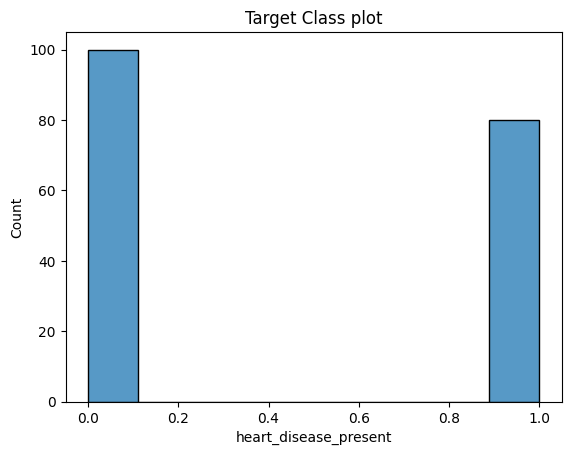

In [ ]:
# Plotting the countplot for target column to see whether it is balanced data or not balnced data.
sns.histplot(data = data,x = "heart_disease_present")
plt.title("Target Class plot")
plt.xlabels = ["1 = heart_disease, 0  = no_heart_disease"]
plt.ylabels = ('count')
plt.show()

In [ ]:
df = data['heart_disease_present'].value_counts()
df

,count
heart_disease_present,
0,100
1,80


**Insights**: This is unbalanced data

<Axes: xlabel='age', ylabel='Count'>

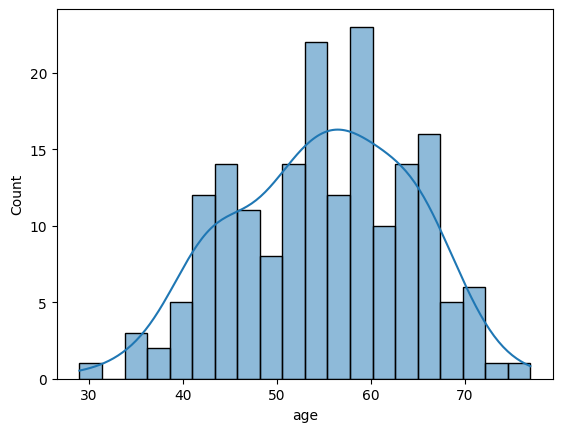

In [ ]:
# Univariate Analysis for single column of Numerical features
sns.histplot(data['age'],kde=True,bins=20)

**Insight** :Patients aged above 55 shows a higher risk of heart disease, indicating age as strong risk factor.

<Axes: xlabel='oldpeak_eq_st_depression'>

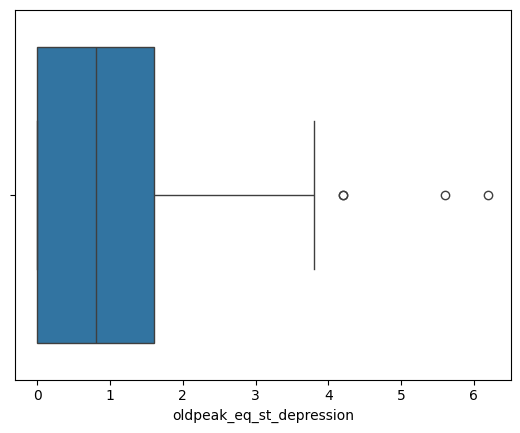

In [ ]:
sns.boxplot(x=data['oldpeak_eq_st_depression'])

<Axes: xlabel='heart_disease_present', ylabel='oldpeak_eq_st_depression'>

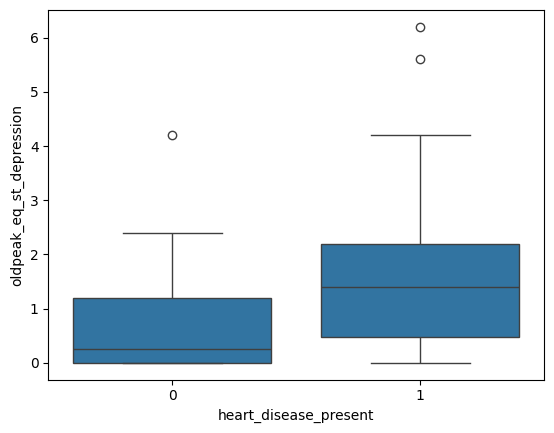

In [ ]:
# Bivariate Analysis
sns.boxplot(x='heart_disease_present',y='oldpeak_eq_st_depression',data=data)

**Insights**: Patient with heart diseasee tend to have higher St depression values than those without heart disease,indicating a strong relationship between oldpeak and heart disease presence.

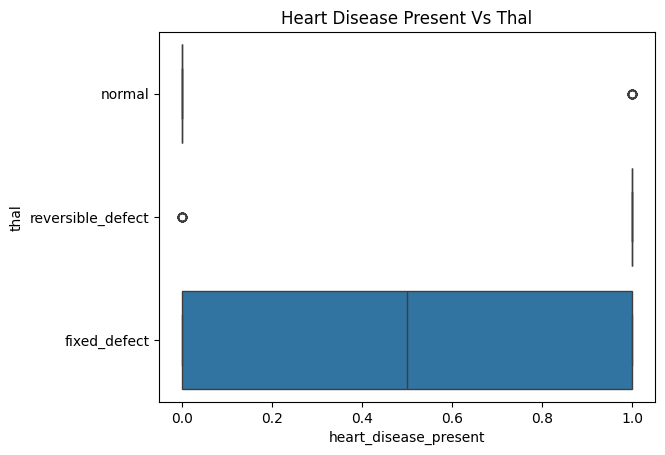

In [ ]:
sns.boxplot(x='heart_disease_present',y='thal',data=data)
plt.title("Heart Disease Present Vs Thal")
plt.show()

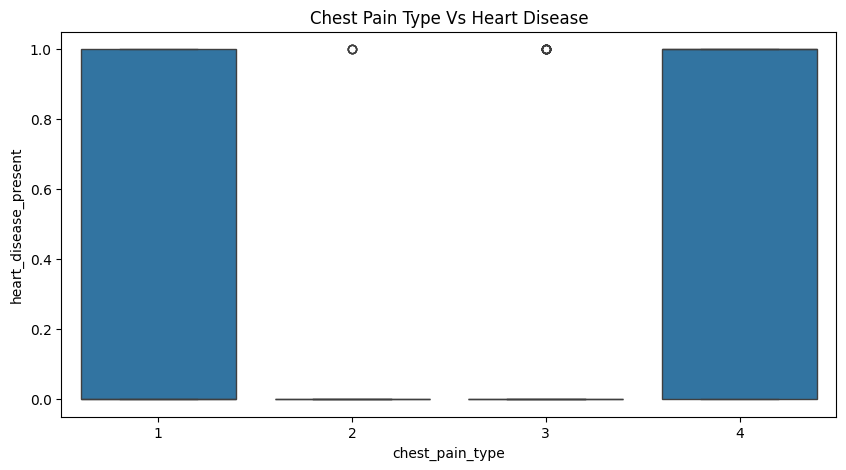

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='chest_pain_type',y='heart_disease_present',data=data)
plt.title("Chest Pain Type Vs Heart Disease")
plt.show()

**Insights**:Chest pain type are strongly associated with heart disease, making this feature highly informative for prediction.

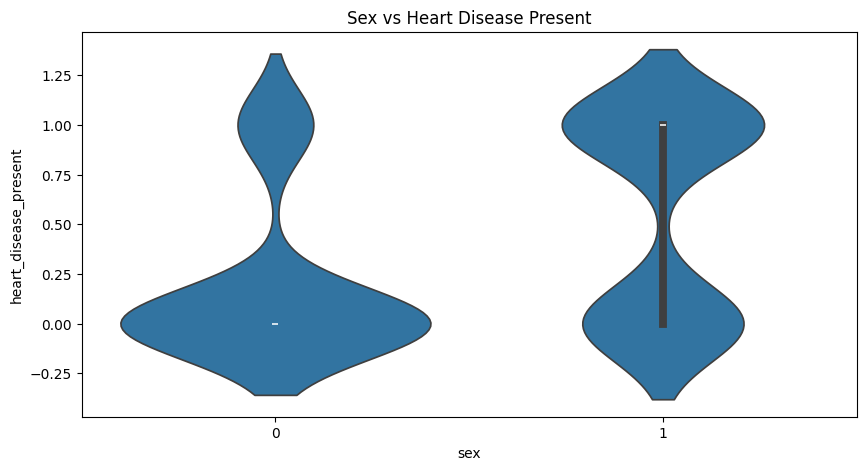

In [ ]:
plt.figure(figsize=(10,5))
sns.violinplot(x='sex',y='heart_disease_present',data=data)
plt.title("Sex vs Heart Disease Present")
plt.show()

**Insights:**
Violin plots were used to see that Male patients exhibit a higher prevalance of heart disease compared to female patients, suggesting gender-based risk difference.

In [ ]:
num_data = data.select_dtypes(exclude=['object'])
corr = num_data.corr()

**Outliers**

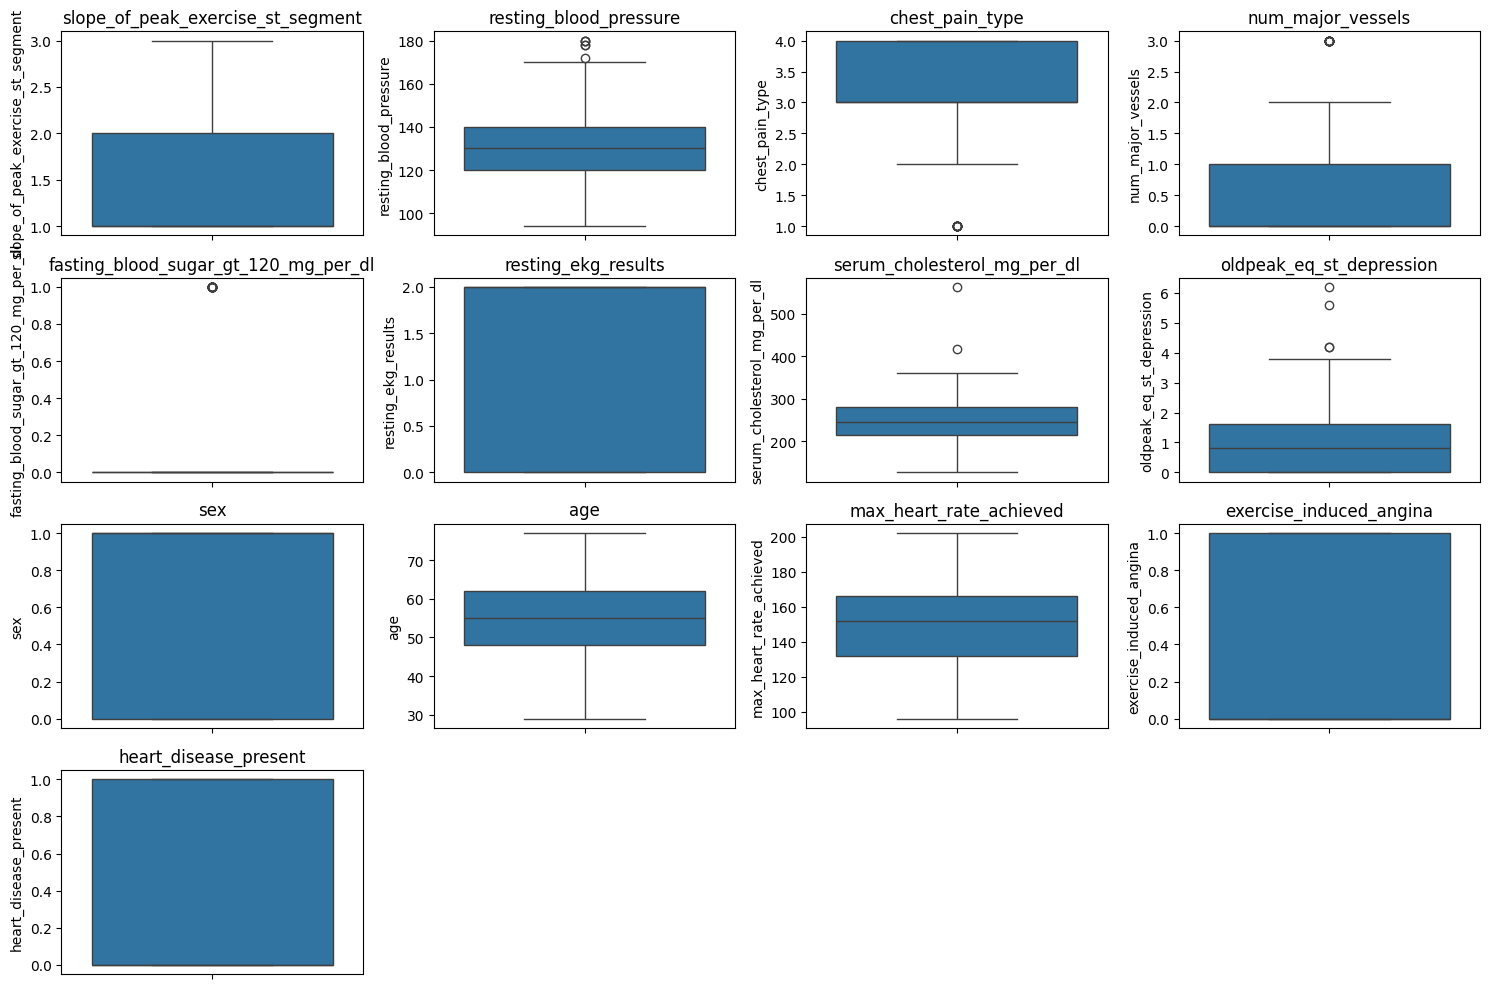

In [ ]:
# Outlier detection plot
num_cols = data.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols,1):
    plt.subplot(4,4,i)
    sns.boxplot(y = data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Outliers were detected using the iqr method.However, they were retained because tree-based models and logistic regression with regularization are roubust to moderate outliers.

In [ ]:
cat_cols = data.select_dtypes(include=['object'])

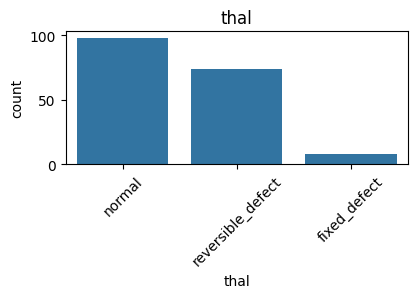

In [ ]:
# categorical colum plot
plt.figure(figsize=(15,10))
for i, col in enumerate(cat_cols,1):
    plt.subplot(4,4,i)
    sns.countplot(x=data[col])
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
num_cols = data.select_dtypes(include=['int64','float64'])

In [ ]:
# Handling Outliers
def handle_outlier_iqr(data,column):
  q1 = data[column].quantile(0.25)
  q3 = data[column].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  outliers = data[(data[column]<lower_bound) | (data[column]>upper_bound)]
  print("\n----------")
  print(f"{column}: {len(outliers)} outliers")
for col in num_cols:
  handle_outlier_iqr(data,col)


----------
slope_of_peak_exercise_st_segment: 0 outliers

----------
resting_blood_pressure: 6 outliers

----------
chest_pain_type: 13 outliers

----------
num_major_vessels: 14 outliers

----------
fasting_blood_sugar_gt_120_mg_per_dl: 29 outliers

----------
resting_ekg_results: 0 outliers

----------
serum_cholesterol_mg_per_dl: 2 outliers

----------
oldpeak_eq_st_depression: 4 outliers

----------
sex: 0 outliers

----------
age: 0 outliers

----------
max_heart_rate_achieved: 0 outliers

----------
exercise_induced_angina: 0 outliers

----------
heart_disease_present: 0 outliers


**Feature Engineering**

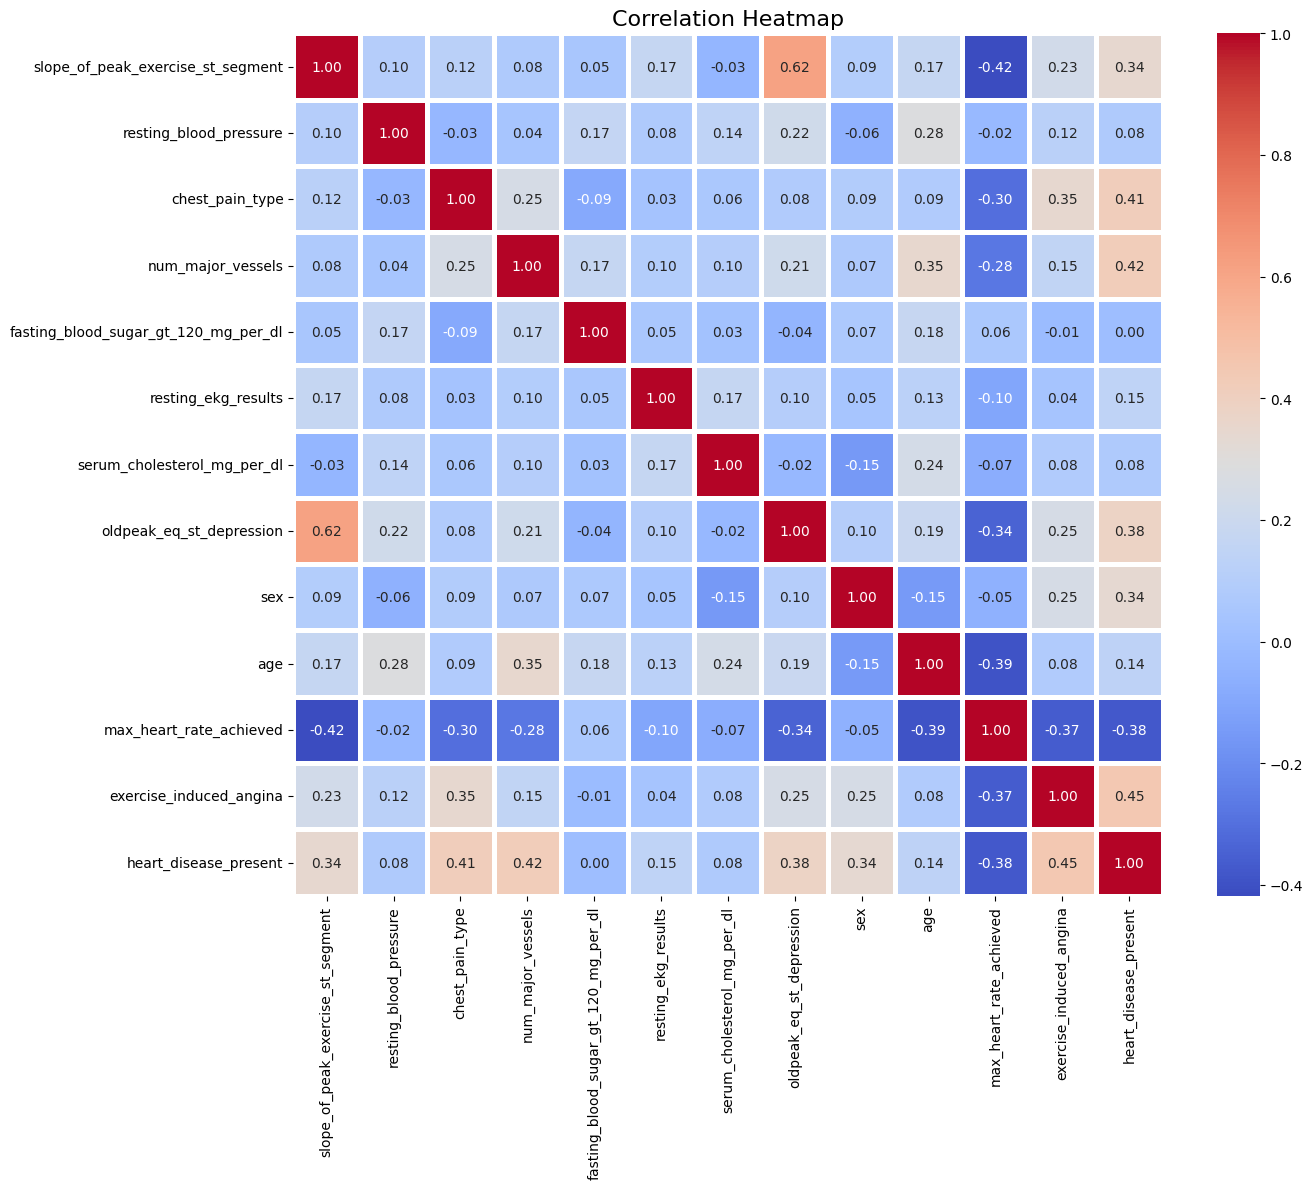

In [ ]:
plt.figure(figsize=(14,12))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",linewidths=2.5,cbar=True)
plt.title("Correlation Heatmap",fontsize=16)
plt.tight_layout()
plt.show()

**Training the Data**

In [ ]:
# Divide the data into input and target
x = data.drop("heart_disease_present",axis=1)
y = data["heart_disease_present"]

In [ ]:
# Training the maximum data will be sent for model is 80% and testing minimum data 20% data will be for testing
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y)

**SMOTE**

In [ ]:
# Identify categorical and numerical columns
categorical_cols = x_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = x_train.select_dtypes(include=['int64','float64']).columns.tolist()

In [ ]:
# Create Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numerical_cols),
        ('cat',OneHotEncoder(drop='first',handle_unknown='ignore'),categorical_cols)
    ]
)

In [ ]:
# Use imbalanced learn pipeline
from imblearn.pipeline import pipeline as ImbPipeline

In [ ]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [ ]:
# Applied smote to handle the class imbalance
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_processed, y_train)
print(f"Original training set shape: {Counter(y_train)}")
print(f"Resampled training set shape: {Counter(y_train_smote)}")

Original training set shape: Counter({0: 80, 1: 64})
Resampled training set shape: Counter({0: 80, 1: 80})


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_cols = ['thal']
# numeric_cols = ['age']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

pipeline.fit(x_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['slope_of_peak_exercise_st_segment',
                                                   'resting_blood_pressure',
                                                   'chest_pain_type',
                                                   'num_major_vessels',
                                                   'fasting_blood_sugar_gt_120_mg_per_dl',
                                                   'resting_ekg_results',
                                                   'serum_cholesterol_mg_per_dl',
                                                   'oldpeak_eq_st_depression',
                                                   'sex', 'age',
                                                   'max_heart_rate_achieved',
                                                   'exercise_induced_angina']),
                                                 ('cat', OneHotEncoder(),
                                                  ['thal'])])),
                ('model', LogisticRegression())])

In [ ]:
data['thal'].unique()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['thal'] = le.fit_transform(data['thal'])

In [ ]:
# from imblearn.over_sampling import SMOTE
# smote = SMOTE(random_state=42)
# x_res,y_res = smote.fit_resample(x_train,y_train)
# plt.figure(figsize=(5,4))
# sns.countplot(x=y_res)
# plt.title("Class Distribution")
# plt.show()

**Algorithm**

In [ ]:
# Mutltiple machine learning models were trained to identify the most suitable algorithm for heart disease present.
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
models={
    "Logistic Regression":LogisticRegression(max_iter=1000,class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42),
    "XGBoost":XGBClassifier(n_estimators=300,learning_rate=0.05,subsample=0.8,colsample_bytree =0.8,eval_metric='logloss',random_state=42),
    "GradientBoosting":GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42),
    "SVM":SVC(kernel='rbf',probability=True,class_weight='balanced',random_state=42)
}

In [ ]:
# Smote
from imblearn.pipeline import Pipeline as ImbPipeline
smote = SMOTE(random_state=42,k_neighbors=5)
x_train_resampled,y_train_resampled = smote.fit_resample(x_train_processed,y_train)
print(f"Before Smote:,{Counter(y_train)}")
print(f"After Smote:,{Counter(y_train_resampled)}")

Before Smote:,Counter({0: 80, 1: 64})
After Smote:,Counter({0: 80, 1: 80})


In [ ]:
preprocessor_fitted = preprocessor.fit(x_train)
x_train_processed = preprocessor_fitted.transform(x_train)
x_test_processed = preprocessor_fitted.transform(x_test)

In [ ]:
from sklearn.metrics import roc_auc_score
results = []
for name,model in models.items():
  pipeline = ImbPipeline(steps=[
      ('preprocessor',preprocessor),
      ('smote',SMOTE(random_state=42)),
      ('Classifier',model)
  ])
  pipeline.fit(x_train,y_train)
  y_pred = pipeline.predict(x_test)

  if hasattr(model,"predict_proba"):
    y_prob = pipeline.predict_proba(x_test)[:,1]
    roc_auc = roc_auc_score(y_test,y_prob)
  else:
    roc_auc = np.nan

  results.append({
    'Model':name,
    'Accuracy':accuracy_score(y_test,y_pred),
    'Precision':precision_score(y_test,y_pred),
    'Recall':recall_score(y_test,y_pred),
    'F1 Score':f1_score(y_test,y_pred),
    'ROC-AUC':roc_auc
})

**Model Comparison Table:**

In [ ]:
results_df = pd.DataFrame(results).sort_values(by='Accuracy',ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,GradientBoosting,0.916667,0.842105,1.0000,0.914286,0.956250
1,Random Forest,0.888889,0.800000,1.0000,0.888889,0.959375
0,Logistic Regression,0.833333,0.777778,0.8750,0.823529,0.943750
2,XGBoost,0.833333,0.750000,0.9375,0.833333,0.953125
4,SVM,0.805556,0.736842,0.8750,0.800000,0.943750


In [ ]:
rf_result=None
gb_result=None
for res in results:
  if res["Model"] == "Random Forest":
    rf_result = res
  elif res["Model"] == "GradientBoosting":
    gb_result = res

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# For Random Forest
rf_model_obj = models["Random Forest"]
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor',preprocessor),
    ('smote',SMOTE(random_state=42)),
    ('Classifier',rf_model_obj)
])

rf_pipeline.fit(x_train,y_train)
y_pred_rf = rf_pipeline.predict(x_test)

# For Gradient Boosting
gb_model_obj = models["GradientBoosting"]
gb_pipeline = ImbPipeline(steps=[
    ('preprocessor',preprocessor),
    ('smote',SMOTE(random_state=42)),
    ('Classifier',gb_model_obj)
])
gb_pipeline.fit(x_train,y_train)
y_pred_gb = gb_pipeline.predict(x_test)

**Confusion Matrix for recall which got 1.000:**

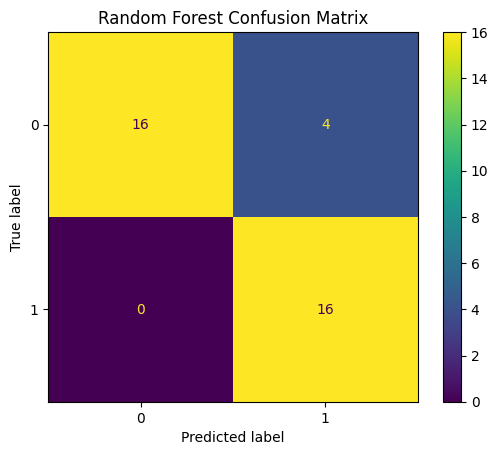

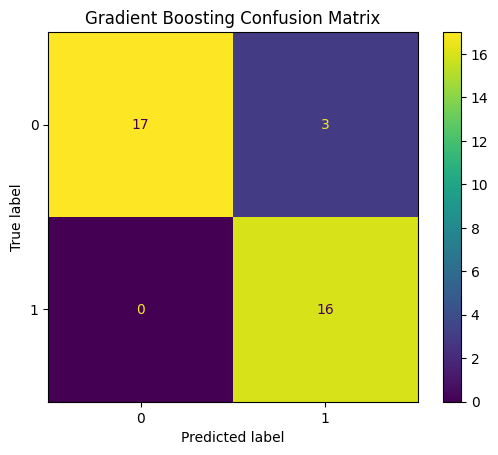

In [ ]:
# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test,y_pred_rf)
disp_rf = ConfusionMatrixDisplay(cm_rf)
disp_rf.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

# Confusion matrix for Gradient Boosting
cm_gb = confusion_matrix(y_test,y_pred_gb)
disp_gb = ConfusionMatrixDisplay(cm_gb)
disp_gb.plot()
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

**Insights:**
Both random forest and gradient boosting recall is 1.000, as shown by the confusion matrix that indicates that model didn't produce any false negatives all patients with heart disease were  correctly identified.

In health care applications, recall is more important than accuracy because missing a patient with heart disease can have serious consequences.

In [ ]:
from sklearn.metrics import roc_curve,auc

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compare ROC curve for all models
def plot_roc_curves(models, preprocessor, x_train, y_train, x_test, y_test):
    plt.figure(figsize=(10,6))

    for name, model in models.items():
        pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])

        pipeline.fit(x_train, y_train)

        if hasattr(model, "predict_proba"):
            y_prob = pipeline.predict_proba(x_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_auc = auc(fpr, tpr)

            plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison Across Models")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


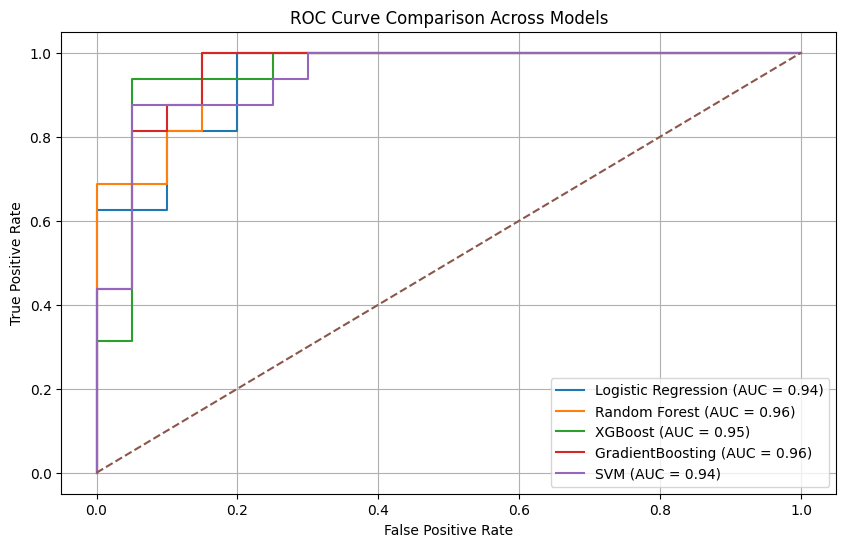

In [ ]:
plot_roc_curves(
    models=models,
    preprocessor=preprocessor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)



**Insights:**
The ROC-AUC curve lie well above all the models approximately greater than (>0.93) and the model also shows high AUC values.The initial curves indicate high recall with low false positives. ROC-AUC is reliable for this imbalanced dataset.

**Model Selection and Final Decision:**
Both RandomForest and Gradient Boosting achieved good accuracy, precision and recall.But,I selected GradientBoosting as the final model due to its better interpretability,robustness on small dataset and feature importance in healthcare context.High recall for heart disease cases were prioritized to minimize false negative.

**Challenges Faced:**
* The understanding of medical features.
* Outliers were detected in many columns(i.e.Chloestral,Resting Blood Pressure,ST depression).
* To prevent data leakage ,use scaling and pipelines.
* Tried mulitple models this introduced the challenge of model overfitting and to avoid underfitting.
* Choose the right evaluation metrics,because accuracy alone is misleading.
* Handle outliers (remove/cap)based on the medical features.



**Future Scope**: The performance of the model is limited by the small dataset size with access to larger and more diverse patient data, the model can be further imporved using advanced feature engineering,cost-sensitive learning.

**Suggestions to Hospital**:

*  The model can be used as an early screening tool to identify individuals at higher risk of heart disease.
*  The model should be used as a decision support system.
*  Patients predicted as high risk can be recommended for further clinical evaluation and medical test by healthcare professionals.





This model demonstrates strong predictive performance with high ROC-AUC, indicating reliable separation between patients with and without heart disease, making it suitable for preliminary clinical decision support.